[2026-08-05 16:40:05] [info     ] 计算因子，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59


[2026-08-05 16:44:37] [info     ] 读取因子库，区间：2024-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 16:44:37] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 16:44:39] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 16:44:39] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-05 16:44:39] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-05 16:44:39] [info     ] ========== 数据检查 ==========
[2026-08-05 16:44:39] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset

时段,IC
2024-01-15~2024-02-08,0.0250
2024-09-24~2024-10-08,0.0894

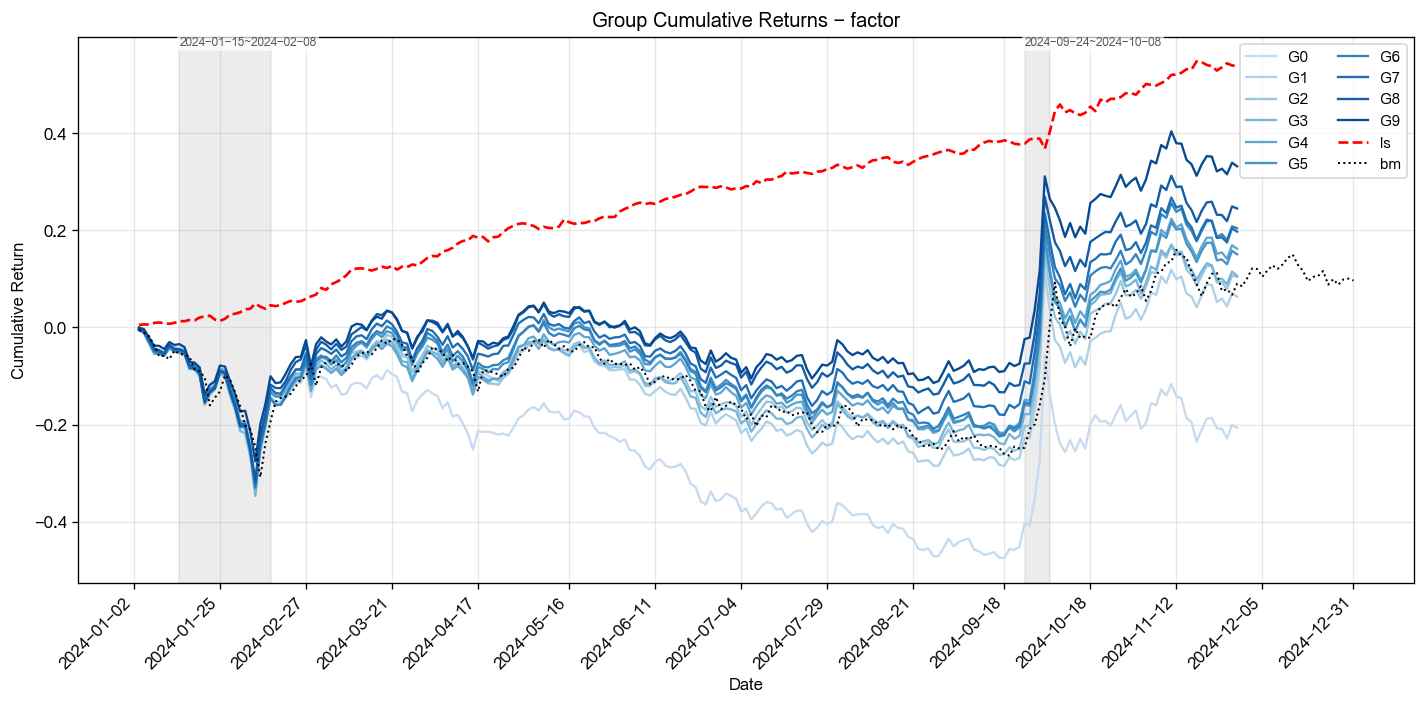
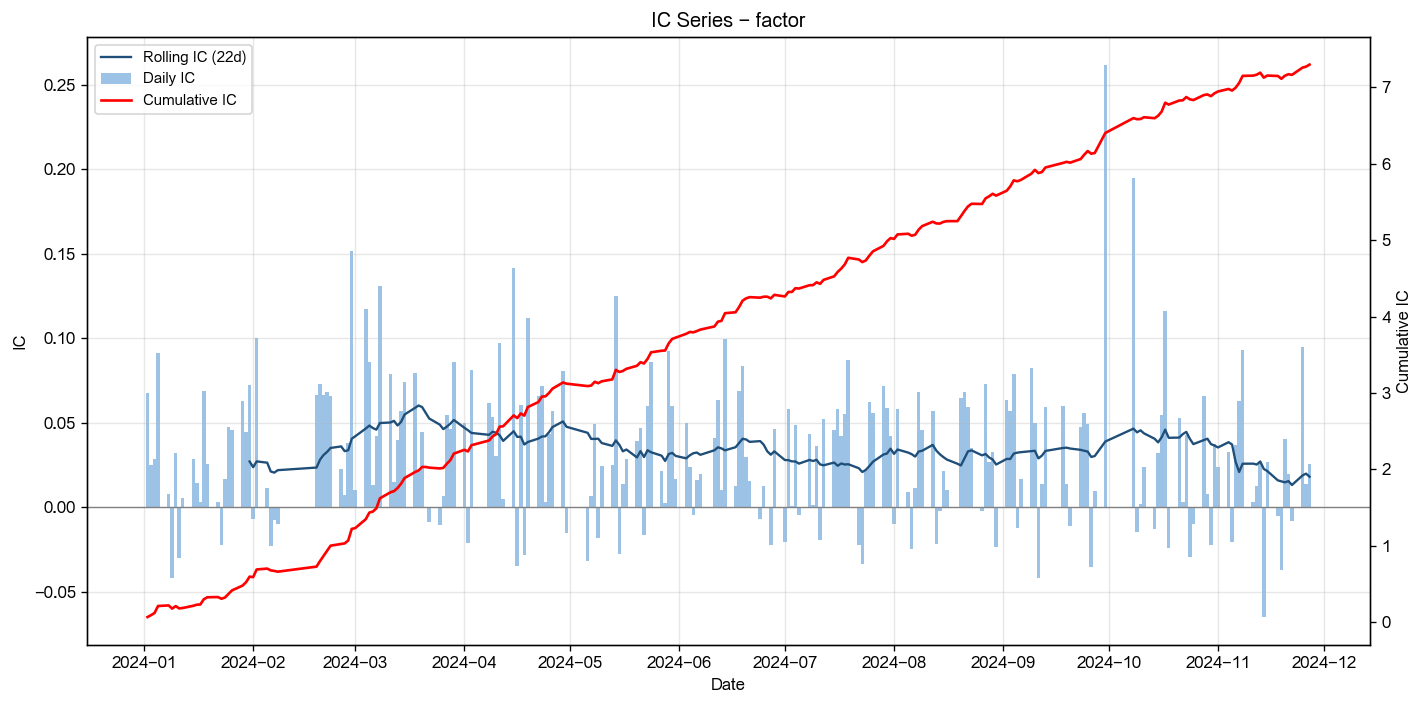
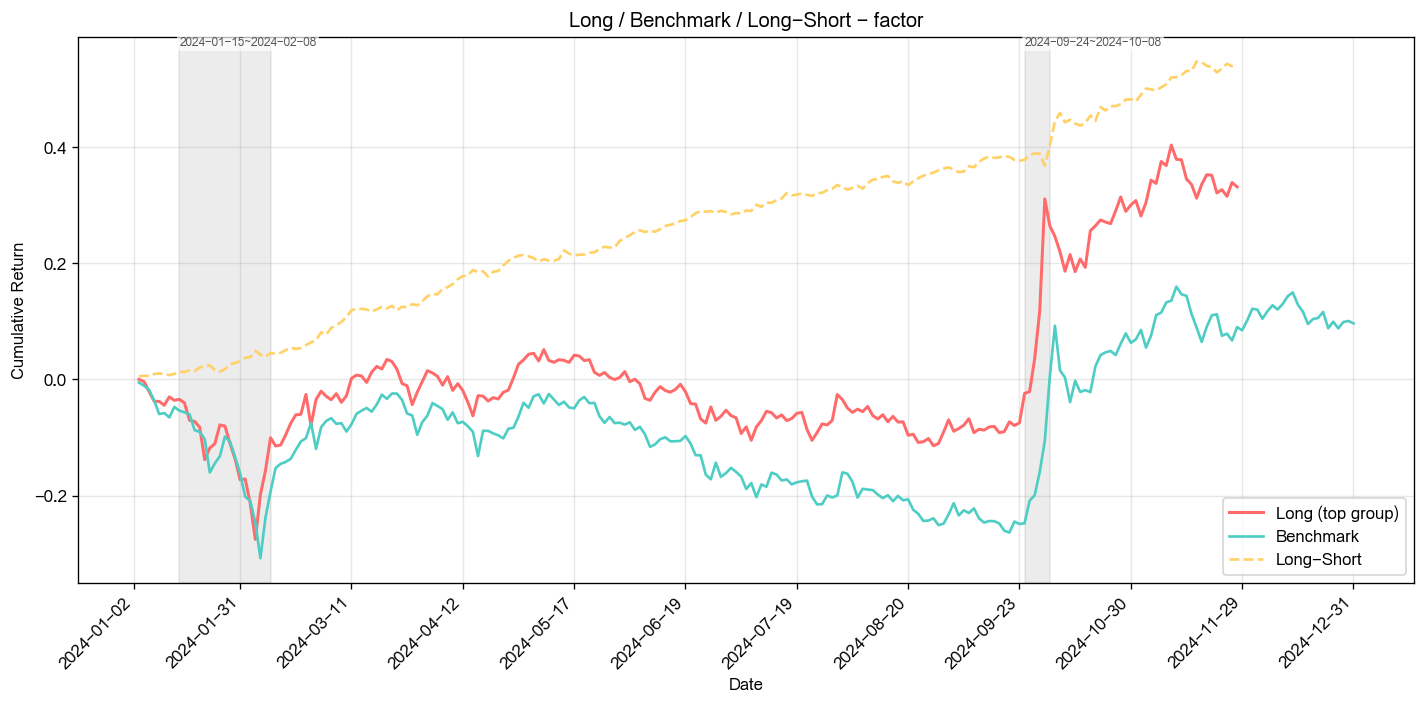
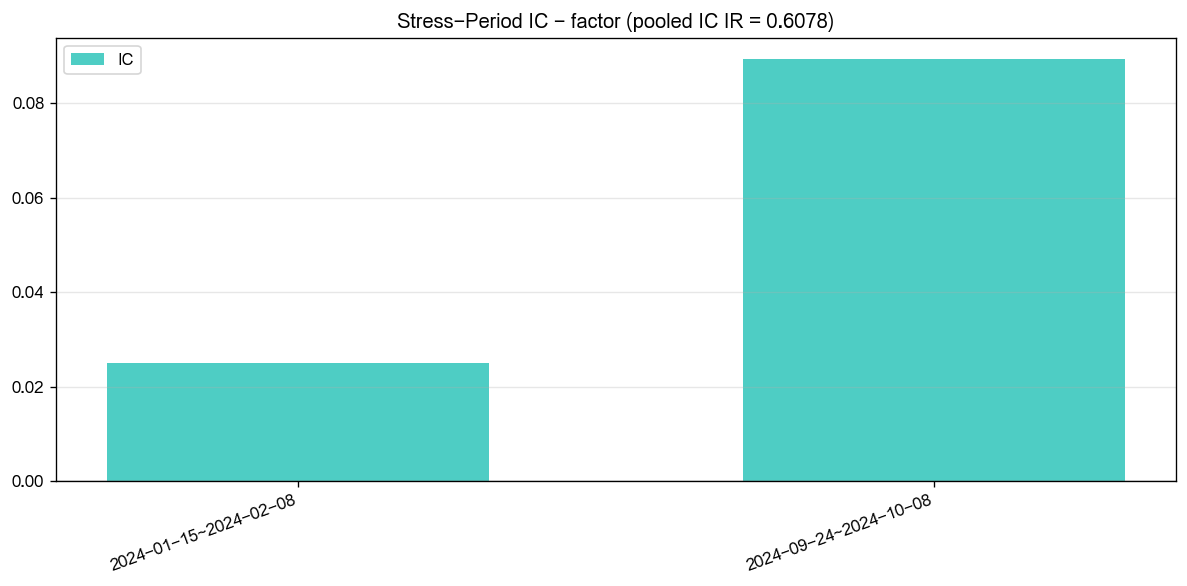
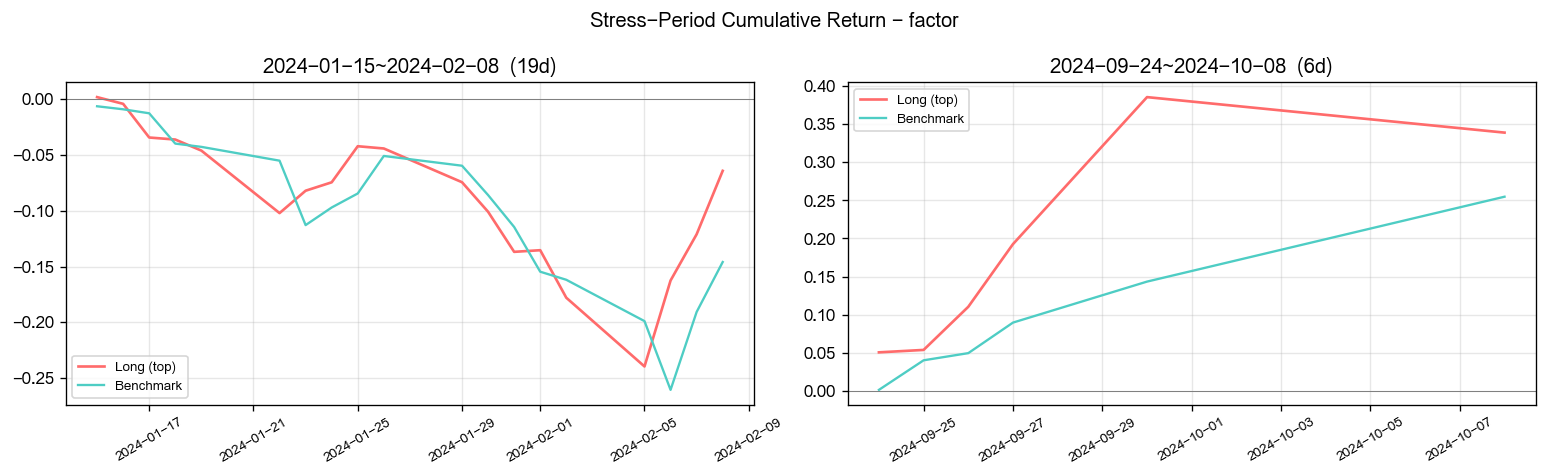

[2026-08-05 16:46:14] [info     ] ========== 因子池回归 ==========
[2026-08-05 16:46:14] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-05 16:46:14] [info     ] 获取收益率数据, 耗时: 0.572 秒
[2026-08-05 16:46:15] [info     ] 滚动 Elastic Net 拟合, 耗时: 1.0783 秒
[2026-08-05 16:46:15] [info     ] 统计 回归结果, 耗时: 0.0068 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,factor,2.5966,0.0337,0.0130,1.0000
2,rsi_12,1.8550,0.0442,0.0238,1.0000
3,amount,1.8285,0.0180,0.0098,1.0000
4,net_profit_rate_ttm,1.7286,0.0036,0.0021,0.9000
5,pb,1.5375,0.0102,0.0066,0.9000
6,gross_profit_rate_ttm,1.4684,0.0067,0.0046,1.0000
7,ps_ttm,1.4526,0.0039,0.0027,1.0000
8,cci_14,1.3854,0.0338,0.0244,1.0000
9,volume,1.3840,0.0138,0.0100,1.0000
10,netflow_amount_main,1.3477,0.0222,0.0165,0.9000

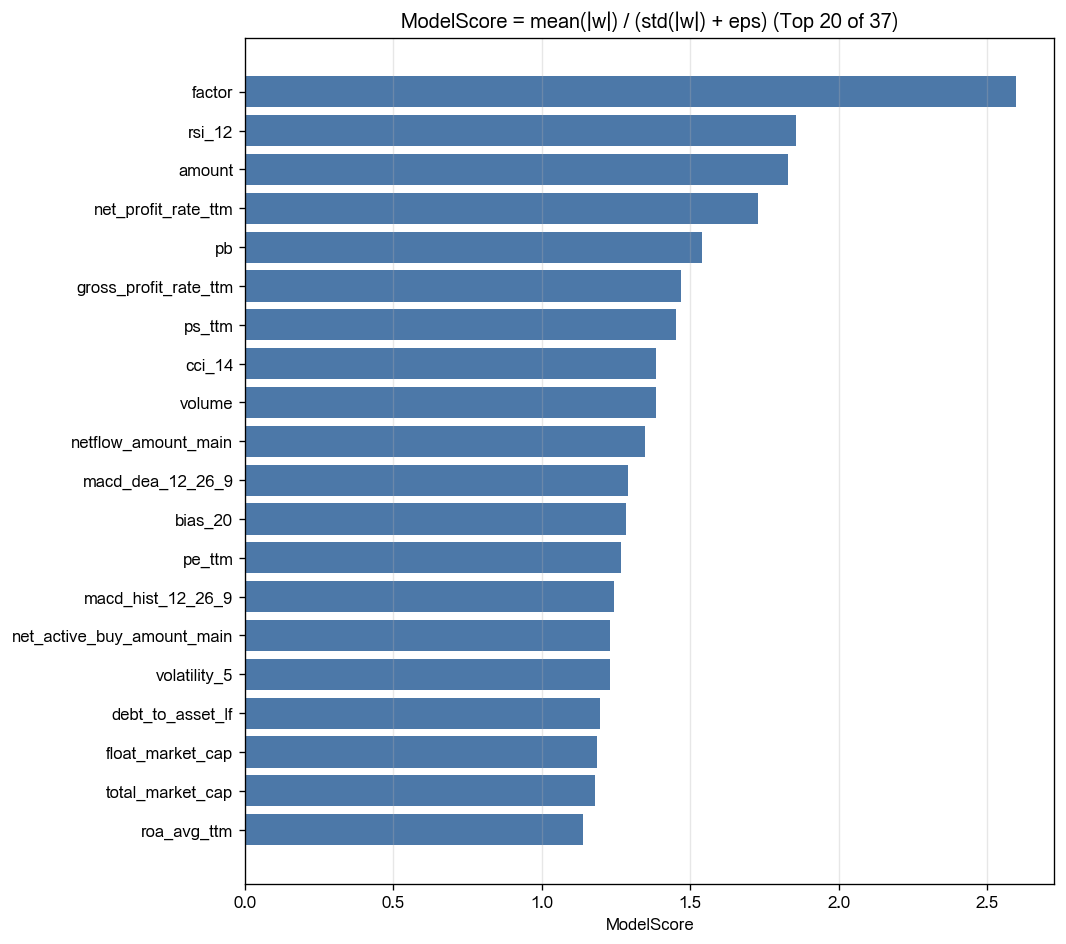
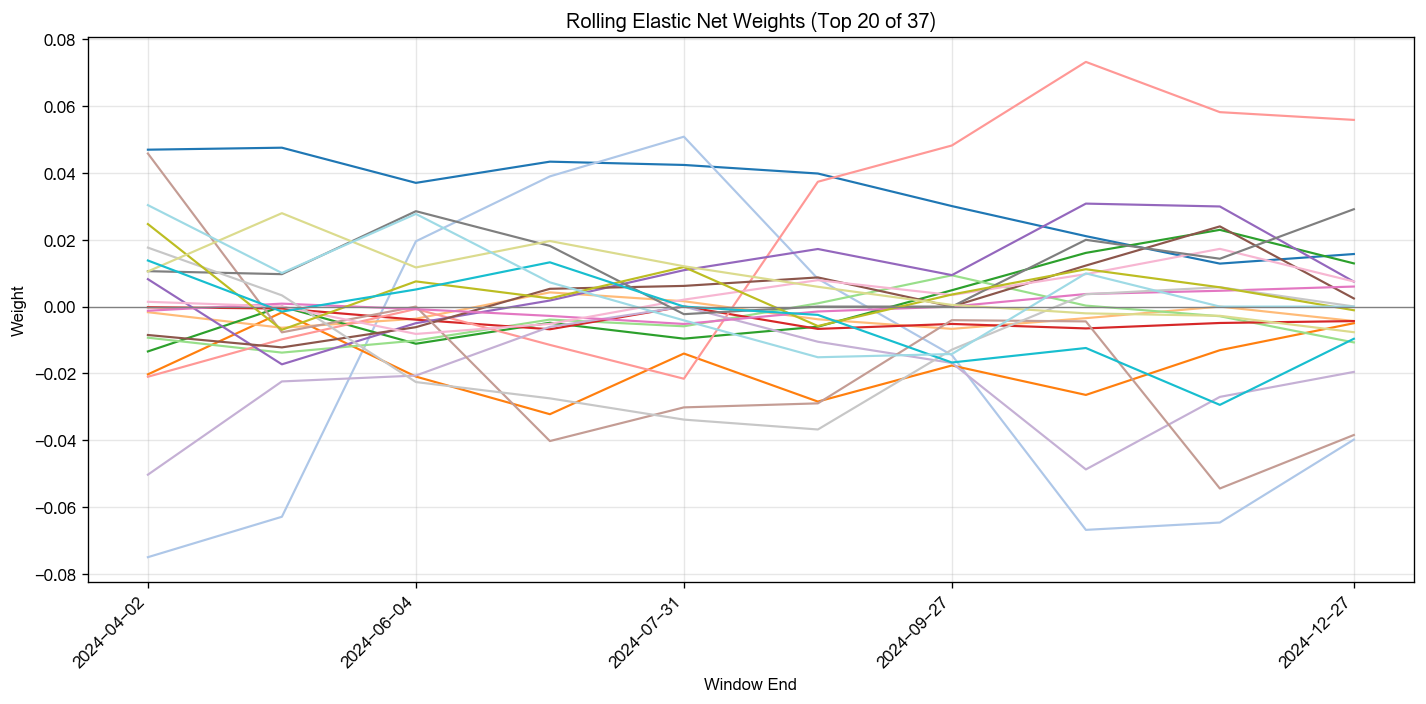
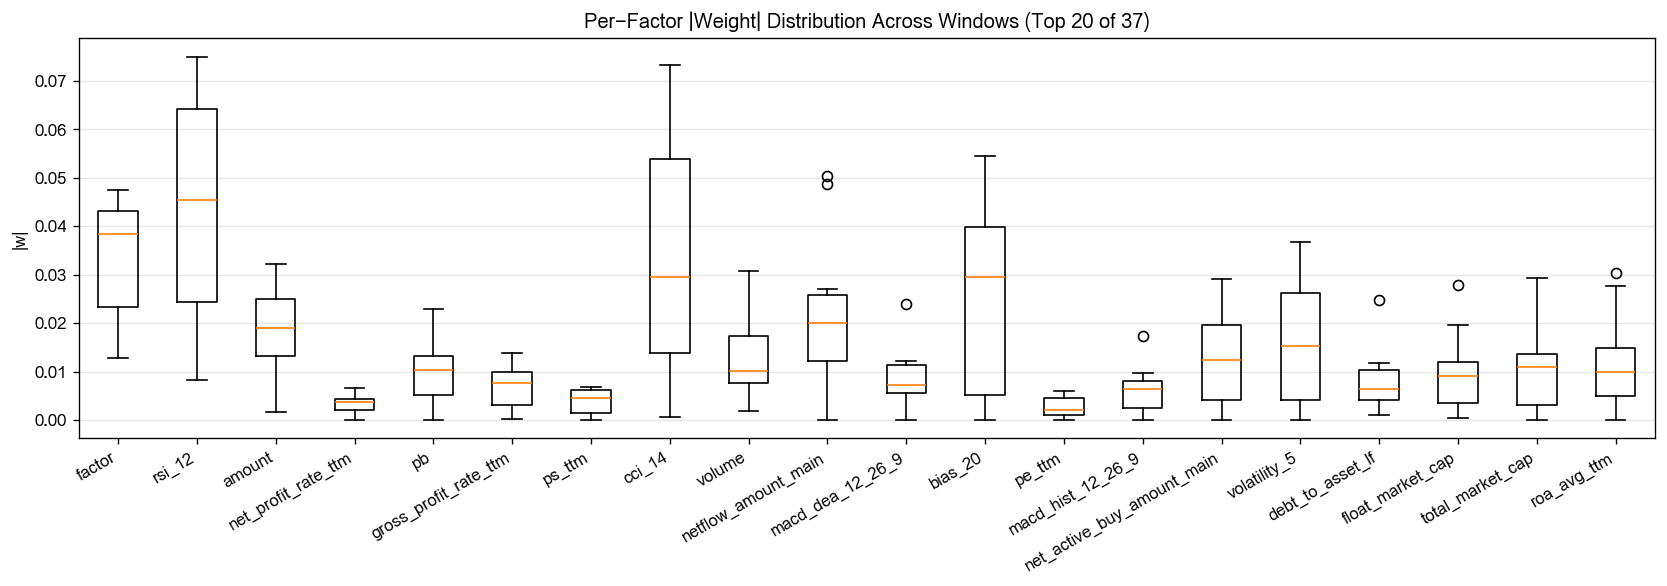
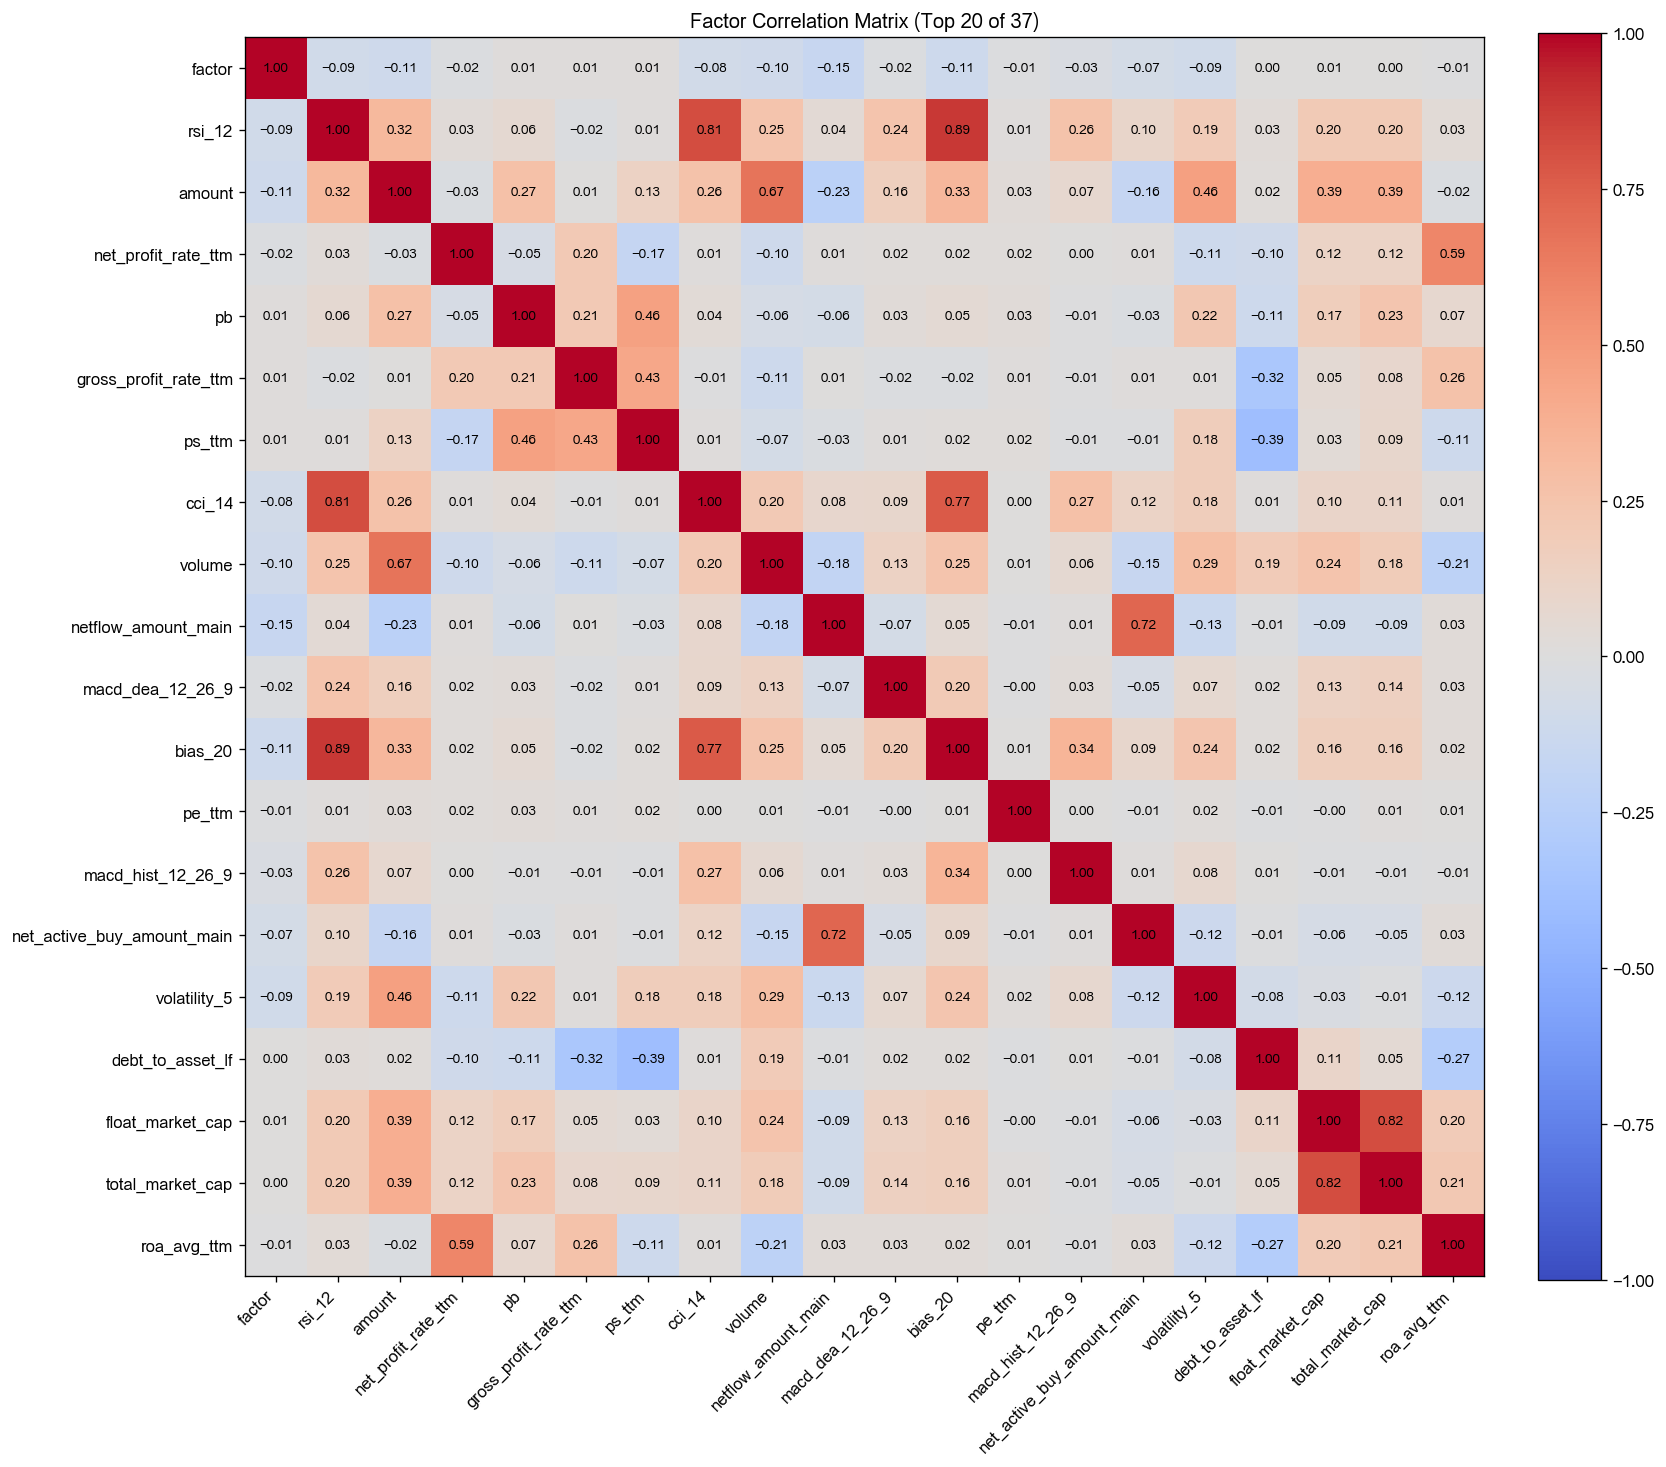

[2026-08-05 16:46:17] [warning  ] 返回的Outputs实例(size=34838166) 大于 64K, 将不会被缓存
[2026-08-05 16:46:17] [info     ] bigalpha_eval.v4 运行完成 [97.911s].


In [1]:
# -*- coding: utf-8 -*-
"""
因子: GP 挖掘簇1 v3 —— 尾盘反转×微结构复合(o2o 真口径) —— 本地/AIStudio 通用

来源表达式同 gp_tail_micro_v2 (factor_out/gp_survivors_o2o.json 首条,
train ic -0.0422/ir -1.081, valid ic -0.0281/ir -0.681, dir=-1):
    add(add(add(add(add(microprice_dev_mean, ret_tail30),
        add(ret_tail30, ret_top5_sum)), ts_decay_5(microprice_dev_mean)),
        add(add(add(oib_mean_tail30, ret_top5_sum), hurst_ret),
        add(add(ret_kurt, volume_share_tail30),
            ts_rank_10(avg_trade_size_tail30)))), volume_share_tail30)
摊平 = -( Z[micro] + 2·Z[ret_tail30] + 2·Z[ret_top5_sum] + ts_decay_5(Z[micro])
        + Z[oib_mean_tail30] + Z[hurst_ret] + Z[ret_kurt]
        + 2·Z[volume_share_tail30] + ts_rank_10(Z[avg_trade_size_tail30]) )

**v3 不是 v2 的等价重写, 是四项平台侧修正** —— v2 在平台上算出来的并不是
挖掘端那个因子(本地跑不出差异, 因为本地数据没有这些形态):
1. **宇宙列限制**: v2 直接透视 SQL 返回的全部 instrument 做截面 winsor/zscore,
   而平台 bar1m 是全市场超集(~1.9×, 见 platform_eval_notes), 挖掘端截面只有
   宇宙内股票 —— v2 的每一格 z 值都被非宇宙股拉偏。v3 按
   `DISTINCT instrument FROM bigalpha_2026_instruments` 定列(同 gp_ck_* 批)。
2. **确定性加固**: v2 用 AVG/STDDEV_POP/SUM 原生浮点聚合, 并行合并顺序不定,
   实测同输入两跑 11226/20777 格不一致(max 3.5e-14) —— 正是平台截断式未来
   函数检测误报的病因。v3 改 DECIMAL 矩量和 + 整数 SUM + 有序 LIST 切片
   (写法照抄已出分的 gp_ck_c6 / gp_ck_c102), 统计量 pandas 重算;
   终端 f32 量化(挖掘端 npz 本就是 float32)+ 输出 round(8) + 固定行序。
3. **零价保护**: 平台真表在停牌/未上市分钟给 close=0, DuckDB 的 LN(0) 抛
   OutOfRangeException(且 0/0=nan 会撞 DECIMAL CAST), 入口 CTE 统一映射成
   NULL(与本地 dai 兼容层同口径)。
4. **240 根完整日**: 挖掘端 builder 丢弃非 240 行的股票日, v2 没有这道过滤,
   平台半日/首日会多出挖掘端没有的值。v3 补 `HAVING COUNT(*) = 240`。
本地数据(每股票日恰 240 根、无零价、bar1m 是宇宙内子集)下 1/3/4 项均为
恒等变换, 所以 v2/v3 的本地金标准都过 —— 差异只在平台侧显形。

终端口径(每股票日, 240 根分钟线; 比率/收益/统计量均量纲无关):
    micro                = 微观价 (b1·av1+a1·bv1)/(av1+bv1) 相对 close 偏离的日内均值
                           (掩码: 双边报价>0 且 av1+bv1>0)
    ret_tail30           = ln(close_15:00 / close_14:30)
    ret_top5_sum         = 当日 239 个分钟对数收益中最大 5 个之和
    oib_mean_tail30      = 尾盘30分钟三档委托失衡 (tb-ta)/(tb+ta) 均值(tb+ta>0)
    hurst_ret            = 对数价格路径聚合方差法 Hurst: lag 2..19 的
                           std(logp_t - logp_{t-l}) 对 ln(lag) 的对数斜率
    ret_kurt             = 分钟收益总体超额峰度 (由原点矩 E1..E4 合成)
    volume_share_tail30  = 尾盘30分钟成交量占全日比
    avg_trade_size_tail30= 尾盘30分钟 Σamount/Σdeal_number
ts_rank_10 需 10 交易日回看, 查询起点前置 40 自然日, 输出裁剪回评测区间。
聚合块拆成两条查询(日内块 / hurst 矩量块)降单条峰值, 照 gp_ck_c62 先例。

本地验证 (2026-08-05, 2024-03 全月 21000 格 / 金标准窗 2023-10-09~12-29):
- 金标准 `scripts/verify_tail_micro_v3.py`: 60 天 spearman
  **min=median=1.000000**, 首日覆盖 共同 992 / 仅金标准 0 / 仅平台版 0
  (v2 同窗同分, 两版在本地都忠实于挖掘端)
- 确定性 `scripts/verify_zero_close_guard.py`: 同输入两跑**逐位相同**
  (v2 为 11078 格不一致 / max 3.7e-14)
- 零价注入(整日停牌 / 盘中停牌两只非宇宙内假股票): 不抛异常, 且池内输出
  **逐位不变**; 同一注入下 v2 与 gp_fin14v_ret_pm 因无宇宙限制被污染
  (后者盘中停牌注入实测池内最大变 9.5e-2, 即"全市场超集挤进截面"的量级)
- v3 vs v2 本地 maxdiff 1.0e-6 (仅终端 f32 量化所致, pearson 1-1.3e-15) ——
  本地看几乎同一因子, 上面四项修正只在平台侧显形
残留风险(本地不可测): 每季两条查询, 条数是 v2 的两倍, 单条峰值减半但墙钟
总时长上升 —— 若平台限的是总时长而非单条资源, 应回退成单查询(见
platform_eval_notes "run error 的第二类病因")。

覆盖率保护 (2026-08-05): 当日池内覆盖率 (当日非空因子值数 / 当日宇宙股票数)
不足 65% 时, 当日缺失的股票沿用**前一交易日**的因子值 —— 防 2020-02-03 千股
跌停一类整截面失效触发平台 run error (判据 = 最差单日覆盖深度)。只读过去,
无前视; 逐日推进故连续低覆盖日顺次传递; 覆盖率达标日的个股缺失不回填 (那是
个股停牌, 不是截面失效)。若区间内每日覆盖率都达标, 本段是恒等变换。
注: 回填值取自已 round(8) 的输出, 不引入新的末位抖动, 确定性加固不受影响。
"""

_LAGS = list(range(2, 20))
_COV_MIN = 0.65   # 当日池内覆盖率下限, 低于此值的交易日启用前一日回填


def main(datasources, start_date, end_date):
    import numpy as np
    import pandas as pd
    import dai

    bar1m_table = datasources["bar1m"]

    univ = dai.query(
        "SELECT DISTINCT instrument FROM bigalpha_2026_instruments",
        filters={"date": ["2019-01-01", "2099-12-31"]},
    ).df()["instrument"]

    # 零价保护: 平台真表停牌/未上市分钟 close=0, DuckDB 的 LN(0) 抛异常而非
    # 返回 NULL, 0/0=nan 还会撞 DECIMAL CAST; 本地兼容层把非正价映射成 NULL,
    # 这里对齐同一口径(对旧版能跑通的输入是恒等变换)
    px_cte = f"""
    px AS (
        SELECT date, instrument, volume, amount, deal_number,
               bid_price1, ask_price1,
               bid_volume1, bid_volume2, bid_volume3,
               ask_volume1, ask_volume2, ask_volume3,
               CASE WHEN close > 0 THEN close END AS close
        FROM {bar1m_table}
    )"""

    # ---- 查询 1: 日内聚合块 (micro / 尾盘族 / 收益矩 / top5 / 尾盘收益)
    day_sql = f"""
    WITH {px_cte},
    m AS (
        SELECT date::DATE AS day, instrument, date::TIME AS tm,
               volume, amount, deal_number,
               bid_volume1 + bid_volume2 + bid_volume3 AS tb,
               ask_volume1 + ask_volume2 + ask_volume3 AS ta,
               close,
               -- CASE 包住整个表达式: 掩码外的行取值为 NULL, 与优化器是否
               -- 提前求分支无关 (平台有 "FILTER 不保护 CAST 求值" 的前例)
               CASE WHEN bid_price1 > 0 AND ask_price1 > 0
                         AND ask_volume1 + bid_volume1 > 0
                    THEN ((bid_price1 * ask_volume1 + ask_price1 * bid_volume1)
                          / (ask_volume1 + bid_volume1)) / close - 1
               END AS micro,
               LN(close / LAG(close) OVER w) AS r
        FROM px
        WINDOW w AS (PARTITION BY date::DATE, instrument ORDER BY date)
    )
    SELECT day::DATETIME AS date, instrument,
           -- DECIMAL 矩量和: 与并行聚合的浮点合并顺序无关, 两跑逐位一致
           COUNT(micro) AS micro_n,
           CAST(SUM(CAST(micro AS DECIMAL(38,25))) AS DOUBLE) AS micro_s,
           COUNT(*) FILTER (WHERE tm > TIME '14:30:00' AND tb + ta > 0) AS oib_n,
           CAST(SUM(CAST(CASE WHEN tb + ta > 0 THEN (tb - ta) / (tb + ta) END
                         AS DECIMAL(38,25)))
                FILTER (WHERE tm > TIME '14:30:00') AS DOUBLE) AS oib_s,
           -- 整数聚合天然与合并顺序无关 (volume/deal_number 是 BIGINT)
           SUM(CASE WHEN tm > TIME '14:30:00' THEN volume ELSE 0 END) AS vol_tail,
           SUM(volume) AS vol_all,
           CAST(SUM(CAST(amount AS DECIMAL(28,3)))
                FILTER (WHERE tm > TIME '14:30:00') AS DOUBLE) AS amt_tail,
           SUM(CASE WHEN tm > TIME '14:30:00' THEN deal_number ELSE 0 END)
               AS deals_tail,
           COUNT(r) AS r_n,
           CAST(SUM(CAST(r AS DECIMAL(38,25))) AS DOUBLE) AS e_s1,
           CAST(SUM(CAST(r * r AS DECIMAL(38,25))) AS DOUBLE) AS e_s2,
           CAST(SUM(CAST(r * r * r AS DECIMAL(38,25))) AS DOUBLE) AS e_s3,
           CAST(SUM(CAST(r * r * r * r AS DECIMAL(38,25))) AS DOUBLE) AS e_s4,
           -- 有序 LIST 切片: 值级与 ROW_NUMBER top5 一致, 免一次按 r 的排序 pass
           CAST(list_aggregate(list_slice(
                list(r ORDER BY r DESC NULLS LAST), 1, 5), 'sum') AS DOUBLE)
               AS ret_top5_sum,
           -- MAX(CASE 15:00) 与 LAST(ORDER BY date) 在 240 格日逐位等价,
           -- 且与扫描/合并顺序无关
           LN(MAX(CASE WHEN tm = TIME '15:00:00' THEN close END)
              / MAX(CASE WHEN tm = TIME '14:30:00' THEN close END)) AS ret_tail30
    FROM m
    GROUP BY day, instrument
    HAVING COUNT(*) = 240
    """

    # ---- 查询 2: hurst 矩量块 (18 个 lag 的 STDDEV_POP 拆成 n/s/q 三件套)
    lag_cols = ",\n               ".join(
        f"LN(close) - LN(LAG(close, {l}) OVER w) AS d{l}" for l in _LAGS)
    mom_cols = ",\n           ".join(
        f"COUNT(d{l}) AS n{l},\n           "
        f"CAST(SUM(CAST(d{l} AS DECIMAL(38,25))) AS DOUBLE) AS s{l},\n           "
        f"CAST(SUM(CAST(d{l} * d{l} AS DECIMAL(38,25))) AS DOUBLE) AS q{l}"
        for l in _LAGS)
    hurst_sql = f"""
    WITH {px_cte},
    m AS (
        SELECT date::DATE AS day, instrument,
               {lag_cols}
        FROM px
        WINDOW w AS (PARTITION BY date::DATE, instrument ORDER BY date)
    )
    SELECT day::DATETIME AS date, instrument,
           {mom_cols}
    FROM m
    GROUP BY day, instrument
    HAVING COUNT(*) = 240
    """

    buf_start = (pd.Timestamp(start_date) - pd.Timedelta(days=40)).strftime("%Y-%m-%d")
    day_parts, hu_parts = [], []
    for q in pd.period_range(start=buf_start, end=end_date, freq="Q"):
        qs = max(q.start_time, pd.Timestamp(buf_start))
        qe = min(q.end_time.normalize(), pd.Timestamp(end_date))
        filt = {"date": [qs.strftime("%Y-%m-%d 00:00:00"),
                         qe.strftime("%Y-%m-%d 23:59:59")]}
        day_parts.append(dai.query(day_sql, filters=filt).df())
        hu_parts.append(dai.query(hurst_sql, filters=filt).df())
    raw = pd.concat(day_parts, ignore_index=True)
    hu = pd.concat(hu_parts, ignore_index=True)
    for df in (raw, hu):
        df["date"] = df["date"].astype("datetime64[ns]")
    raw = raw.merge(hu, on=["date", "instrument"], how="inner")

    with np.errstate(all="ignore"):
        # ---- 矩量和重算均值类终端 (n=0 -> NaN, 与挖掘端 _masked_mean 一致)
        def _ratio(num, den):
            a = raw[num].to_numpy(np.float64)
            b = raw[den].to_numpy(np.float64)
            return np.where(b > 0, a / np.where(b > 0, b, 1.0), np.nan)

        raw["micro"] = _ratio("micro_s", "micro_n")
        raw["oib_mean_tail30"] = _ratio("oib_s", "oib_n")
        raw["volume_share_tail30"] = _ratio("vol_tail", "vol_all")
        raw["avg_trade_size_tail30"] = _ratio("amt_tail", "deals_tail")

        # ---- ret_kurt: 总体超额峰度, 由原点矩合成 (m2<=0 -> NaN)
        n = raw["r_n"].to_numpy(np.float64)
        e1 = raw["e_s1"].to_numpy(np.float64) / n
        e2 = raw["e_s2"].to_numpy(np.float64) / n
        e3 = raw["e_s3"].to_numpy(np.float64) / n
        e4 = raw["e_s4"].to_numpy(np.float64) / n
        m2 = e2 - e1 ** 2
        m4 = e4 - 4 * e3 * e1 + 6 * e2 * e1 ** 2 - 3 * e1 ** 4
        kurt = m4 / m2 ** 2 - 3.0
        kurt[~(m2 > 0)] = np.nan
        raw["ret_kurt"] = kurt

        # ---- hurst_ret: 矩量和重算 STDDEV_POP 后, ln(tau) 对 ln(lag) 的
        #      OLS 斜率闭式解 (任一 tau<=0 则 NaN, 与挖掘端 _hurst 一致)
        taus = np.empty((len(raw), len(_LAGS)), dtype=np.float64)
        for j, l in enumerate(_LAGS):
            nl = raw[f"n{l}"].to_numpy(np.float64)
            sl = raw[f"s{l}"].to_numpy(np.float64)
            ql = raw[f"q{l}"].to_numpy(np.float64)
            nn = np.maximum(nl, 1.0)
            taus[:, j] = np.where(
                nl >= 1, np.sqrt(np.maximum(ql / nn - (sl / nn) ** 2, 0.0)),
                np.nan)
        lags = np.array(_LAGS, dtype=np.float64)
        xc = np.log(lags) - np.log(lags).mean()
        ln_tau = np.log(taus)
        hurst = ln_tau @ xc / (xc ** 2).sum()
        hurst[~(np.isfinite(ln_tau).all(axis=1) & (taus > 0).all(axis=1))] = np.nan
        raw["hurst_ret"] = hurst

    # ---- 逐日截面 winsorize + zscore (ddof=0, 与挖掘端 prep_terminals 一致)
    terms = ["micro", "ret_tail30", "ret_top5_sum", "oib_mean_tail30",
             "hurst_ret", "ret_kurt", "volume_share_tail30",
             "avg_trade_size_tail30"]
    for c in terms:      # 终端 f32 量化: 挖掘端 npz 本就是 float32, 顺带消抖
        raw[c] = raw[c].astype(np.float32).astype(np.float64)
    didx = pd.DatetimeIndex(np.sort(raw["date"].unique()))
    codes = np.sort(univ.unique())        # 宇宙列限制: 截面 = 宇宙内股票
    piv = {c: raw.pivot_table(index="date", columns="instrument", values=c)
             .reindex(index=didx, columns=codes)
           for c in terms}

    def zscore_rows(df):
        m = df.to_numpy(dtype=np.float64)
        with np.errstate(all="ignore"):
            lo = np.nanquantile(m, 0.01, axis=1, keepdims=True)
            hi = np.nanquantile(m, 0.99, axis=1, keepdims=True)
            m = np.clip(m, lo, hi)
            mu = np.nanmean(m, axis=1, keepdims=True)
            sd = np.nanstd(m, axis=1, keepdims=True)
            m = np.where(sd > 0, (m - mu) / sd, 0.0)
        return pd.DataFrame(m, index=df.index, columns=df.columns)

    z = {c: zscore_rows(df) for c, df in piv.items()}

    # ---- ts 算子 (满窗口语义, 与 gp/ops.py 逐位一致)
    zm = z["micro"]
    decay5 = sum((5 - i) * zm.shift(i) for i in range(5)) / 15.0
    tsrank10 = z["avg_trade_size_tail30"].rolling(10, min_periods=10).rank(pct=True)

    f = -(z["micro"] + 2 * z["ret_tail30"] + 2 * z["ret_top5_sum"] + decay5
          + z["oib_mean_tail30"] + z["hurst_ret"] + z["ret_kurt"]
          + 2 * z["volume_share_tail30"] + tsrank10)   # dir=-1: 统一为正 IC

    out = f.stack().rename("factor").reset_index()
    out.columns = ["date", "instrument", "factor"]
    out = out[(out["date"] >= start_date) & (out["date"] <= end_date)]
    out["factor"] = out["factor"].round(8)   # 吸收浮点末位抖动 (截断检测保险)

    pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    out = pool.merge(out, on=["date", "instrument"], how="left") \
        .sort_values(["date", "instrument"], kind="mergesort") \
        .reset_index(drop=True)              # 输出行序确定 (pool 的 SQL 行序不定)

    # ---- 覆盖率保护 (仅此一段, 上面的计算逻辑一律不动)
    # 当日池内覆盖率 = 当日非空因子值数 / 当日宇宙股票数; 不足 _COV_MIN 的
    # 交易日, 其缺失格子沿用前一交易日的值 (只读过去, 无前视)。逐日推进,
    # 连续低覆盖日顺次传递; 覆盖率达标日的缺失不回填
    uniq = out.drop_duplicates(["date", "instrument"])
    w = uniq.pivot(index="date", columns="instrument", values="factor")
    if len(w) > 1:
        n_pool = uniq.groupby("date").size().reindex(w.index).to_numpy(np.float64)
        cov = w.notna().sum(axis=1).to_numpy(np.float64) / n_pool
        vals = w.to_numpy(dtype=np.float64, copy=True)
        for i in range(1, len(vals)):
            if cov[i] < _COV_MIN:
                miss = np.isnan(vals[i])
                vals[i][miss] = vals[i - 1][miss]
        fill = pd.DataFrame(vals, index=w.index, columns=w.columns) \
            .stack().rename("factor").reset_index()
        fill.columns = ["date", "instrument", "factor"]
        # merge how="left" 保持左表行序, 上面固定好的行序不变
        out = out.drop(columns="factor") \
            .merge(fill, on=["date", "instrument"], how="left")
    return out[["date", "instrument", "factor"]]


if __name__ == '__main__':
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        'bar1m': 'bigalpha_2026_stock_bar1m',
        'financial': 'bigalpha_2026_financial'
        }
    start_date = '2024-01-01 00:00:00'
    end_date = '2024-12-31 23:59:59'

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={'date': [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )


In [2]:
    import numpy as np
    import pandas as pd

    # 保留需要的字段
    df = factor_data[["date", "instrument", "factor"]].copy()

    # 日期统一为 YYYY-MM-DD
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()

    # 转成数值；NaN、inf、-inf 都视为无效因子
    df["factor"] = pd.to_numeric(df["factor"], errors="coerce")
    df["is_valid"] = np.isfinite(df["factor"])

    # 分日统计
    daily_coverage = (
        df.groupby("date", as_index=False)
        .agg(
            total_count=("instrument", "nunique"),
            valid_count=("is_valid", "sum"),
        )
        .sort_values("date")
        .reset_index(drop=True)
    )

    daily_coverage["missing_count"] = (
        daily_coverage["total_count"] - daily_coverage["valid_count"]
    )

    daily_coverage["coverage_rate"] = (
        daily_coverage["valid_count"] / daily_coverage["total_count"]
    )

    # 逐日打印
    print("=" * 82)
    print(f"{'日期':<12} {'股票总数':>10} {'有效数量':>10} {'缺失数量':>10} {'覆盖率':>10}  状态")
    print("=" * 82)

    for row in daily_coverage.itertuples(index=False):
        coverage_pct = row.coverage_rate * 100

        if row.coverage_rate < 0.80:
            status = "⚠️ 低于80%"
        else:
            status = "正常"

        print(
            f"{row.date.strftime('%Y-%m-%d'):<12} "
            f"{row.total_count:>10d} "
            f"{row.valid_count:>10d} "
            f"{row.missing_count:>10d} "
            f"{coverage_pct:>9.2f}%  "
            f"{status}"
        )

    print("=" * 82)

    # 汇总异常日期
    low_coverage = daily_coverage[daily_coverage["coverage_rate"] < 0.80]

    print()
    print(f"交易日总数：{len(daily_coverage)}")
    print(f"覆盖率低于 80% 的交易日数：{len(low_coverage)}")
    print(f"最低覆盖率：{daily_coverage['coverage_rate'].min() * 100:.2f}%")
    print(f"平均覆盖率：{daily_coverage['coverage_rate'].mean() * 100:.2f}%")

    if not low_coverage.empty:
        print("\n⚠️ 覆盖率低于 80% 的日期：")
        for row in low_coverage.itertuples(index=False):
            print(
                f"  {row.date.strftime('%Y-%m-%d')}："
                f"{row.coverage_rate * 100:.2f}% "
                f"（有效 {row.valid_count}/{row.total_count}，"
                f"缺失 {row.missing_count}）"
            )
    else:
        print("\n所有交易日的因子覆盖率均不低于 80%。")

日期                 股票总数       有效数量       缺失数量        覆盖率  状态
2020-03-02         1000        991          9     99.10%  正常
2020-03-03         1000        992          8     99.20%  正常
2020-03-04         1000        996          4     99.60%  正常
2020-03-05         1000        995          5     99.50%  正常
2020-03-06         1000        993          7     99.30%  正常
2020-03-09         1000        994          6     99.40%  正常
2020-03-10         1000        996          4     99.60%  正常
2020-03-11         1000        993          7     99.30%  正常
2020-03-12         1000        994          6     99.40%  正常
2020-03-13         1000        995          5     99.50%  正常
2020-03-16         1000        994          6     99.40%  正常
2020-03-17         1000        992          8     99.20%  正常
2020-03-18         1000        992          8     99.20%  正常
2020-03-19         1000        993          7     99.30%  正常
2020-03-20         1000        994          6     99.40%  正常
2020-03-23         1000 